# Finding Struggling Students
This notebook aims to find a student who attempted most of the 50 problems in the CodeWorkout dataset but achieved very few 100% scores. These students are ideal for mental model analysis because they show more partial progress and errors.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Allow running from project root
sys.path.append(os.getcwd())
sys.path.append('..') # also try parent if inside experiments/

from utils.dataset import load_joined_datasets, get_best_attempts

In [2]:
# 1. Load data
print("Loading joined datasets...")
full_data = load_joined_datasets(verbose=False)

# 2. Get best attempts (highest score per student-problem pair)
print("Extracting best attempts...")
best_attempts = get_best_attempts(full_data, verbose=False)

print(f"Total best attempts: {len(best_attempts)}")

Loading joined datasets...
Extracting best attempts...
Total best attempts: 15375


In [3]:
# 3. Calculate per-student metrics
student_stats = best_attempts.groupby('SubjectID').agg(
    problems_attempted=('ProblemID', 'count'),
    average_score=('Score', 'mean'),
    perfect_scores=('Score', lambda x: (x == 1.0).sum())
).reset_index()

# 4. Calculate success rate (% of 100% scores)
student_stats['success_rate'] = student_stats['perfect_scores'] / student_stats['problems_attempted']

# 5. Filter for students who attempted almost all 50 problems (e.g., >= 45)
struggling_candidates = student_stats[student_stats['problems_attempted'] >= 45].copy()

# Sort by success rate (ascending) to find those who solve many problems but score poorly
struggling_candidates = struggling_candidates.sort_values('success_rate', ascending=True)

print("Top 10 Stretching/Struggling Candidates (Ordered by lowest success rate):")
display(struggling_candidates.head(10))

Top 10 Stretching/Struggling Candidates (Ordered by lowest success rate):


,SubjectID,problems_attempted,average_score,perfect_scores,success_rate
32,10155,46,0.568885,11,0.239130
125,14189,48,0.662050,18,0.375000
343,14476,50,0.775843,21,0.420000
126,14190,48,0.823288,30,0.625000
251,14367,48,0.834132,30,0.625000
196,14308,50,0.863680,34,0.680000
207,14321,49,0.887912,35,0.714286
203,14316,50,0.888486,38,0.760000
309,14438,50,0.873546,38,0.760000
172,14278,48,0.870971,37,0.770833


Top Candidate: Student 10155.0
Problems Attempted: 46.0
Perfect Scores: 11.0 (23.9%)


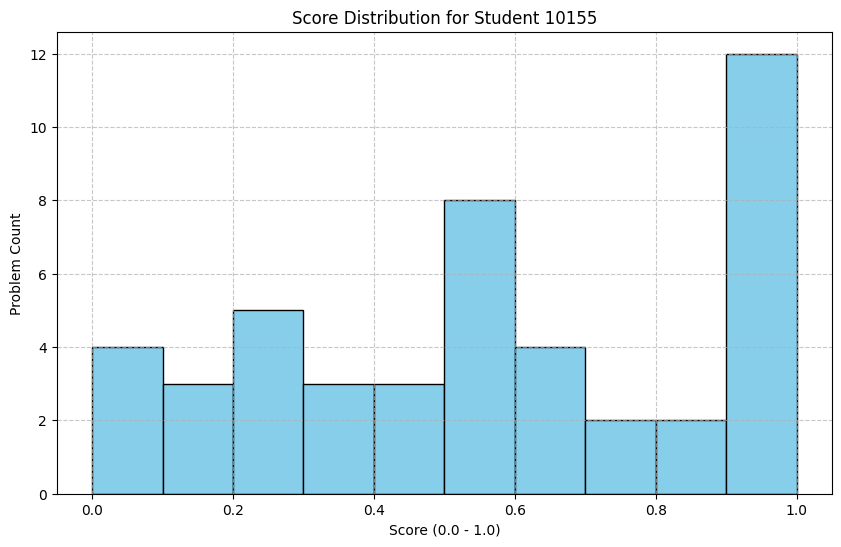

In [4]:
# 6. Choose top student and visualize their performance
top_student = struggling_candidates.iloc[0]
print(f"Top Candidate: Student {top_student['SubjectID']}")
print(f"Problems Attempted: {top_student['problems_attempted']}")
print(f"Perfect Scores: {top_student['perfect_scores']} ({top_student['success_rate']*100:.1f}%)")

# Get this student's scores
student_scores = best_attempts[best_attempts['SubjectID'] == top_student['SubjectID']][['ProblemID', 'Score']]

plt.figure(figsize=(10, 6))
plt.hist(student_scores['Score'], bins=10, color='skyblue', edgecolor='black')
plt.title(f"Score Distribution for Student {int(top_student['SubjectID'])}")
plt.xlabel("Score (0.0 - 1.0)")
plt.ylabel("Problem Count")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()